# Example: Data-Driven Minimum-Variance Portfolios, the Efficient Frontier, and the Capital Allocation Line
In this example, we turn the estimated growth-rate means and covariance of a set of firms into portfolios. We compute the global minimum-variance portfolio in closed form and with a long-only solver, sweep the target growth rate to trace the efficient frontier, add a risk-free asset to find the tangent portfolio and the capital allocation line, and then check how the optimized portfolios did on a year of data the optimizer never saw.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Estimate the inputs from data:__ Compute the sample-mean growth-rate vector and the growth-rate covariance matrix for a chosen set of firms from the 2014 to 2024 training data, and check the volatilities against the L4b parameter table.
> * __Compute minimum-variance portfolios and the frontier:__ Solve the global minimum-variance problem in closed form and with the long-only solver, sweep the target growth rate to trace the efficient frontier, and read the weights along it.
> * __Add a risk-free asset and test out of sample:__ Find the tangent portfolio and the capital allocation line, quote the Sharpe ratio in both conventions, and compare the buy-and-hold wealth of the optimized, equal-weight, and index portfolios on 2025 data.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the [`Include.jl`](Include.jl) file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The [`Include.jl`](Include.jl) file sets paths, loads the required external packages, and includes local helper code. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # Load the local setup file.

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The [`Include.jl`](Include.jl) file loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [CSV.jl](https://csv.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [Distributions.jl](https://juliastats.org/Distributions.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/), and includes the local [`src/Compute.jl`](src/Compute.jl) file. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from January 3, 2014 until December 31, 2024, along with data for several exchange-traded funds and volatility products during that time period. This is the __training__ data: every parameter in this notebook is estimated from it. We also load the __testing__ data, calendar year 2025 (January 2, 2025 until December 31, 2025), which we use only in the last task to see how the portfolios did on prices the optimizer never saw.

Let's load the training data by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep only the firms with the maximum number of trading days (firms with fewer records were acquired or delisted during the period), and store the cleaned data in the `dataset::Dict{String,DataFrame}` variable:

In [2]:
dataset = let

    # Initialize -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # Return
end;

Next, we do the same for the testing data by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), and store the cleaned 2025 data in the `dataset_2025::Dict{String,DataFrame}` variable:

In [3]:
dataset_2025 = let

    # Initialize -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # testing data, calendar year 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # Return
end;

We also load the L4b parameter table into the `parameters_df::DataFrame` variable. Its `volatility` column holds the L4b volatility estimate $\hat{\sigma}=\sigma_{g}\sqrt{\Delta{t}}$ for each firm, and its legacy `drift` column holds L4b's regression estimate of the mean growth rate; we use the table only as a check on what we compute here:

In [4]:
parameters_df = CSV.read(joinpath(_PATH_TO_DATA, "SAGBM-Parameters-Fall-2025.csv"), DataFrame); # L4b parameter table

### Constants
Finally, we set the daily time step, initial wealth, and frontier resolution. We use $g_f=0.041$ per year, the continuously compounded equivalent of the [4.16% one-year Treasury par yield reported for December 31, 2024](https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?field_tdr_date_value_month=202412&type=daily_treasury_yield_curve), as a horizon-matched risk-free growth-rate proxy for the 2025 exercise.

In [5]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
g_f = 0.041; # risk-free growth rate (units: 1/years): continuously compounded equivalent of a one-year Treasury yield of about 4.16% at the end of 2024 (decision date, horizon matched to the 2025 test year)
W₀ = 1000.0; # initial wealth (units: USD)
number_of_points = 101; # number of target growth rates in the frontier sweep

___

## Task 1: Estimate the Inputs for a Chosen Set of Firms
Modern portfolio theory needs two inputs: the expected growth-rate vector and the growth-rate covariance matrix of the assets we are willing to hold. In this task, we estimate both from the training data for a set of firms that we choose, exactly as in the L5a covariance example, but for a handful of firms rather than the whole dataset.

> __Ticker picker question:__ The asset universe changes every result because the optimizer can weight only the firms it receives. For now, we pick a mixed set: technology, semiconductors, banks, automakers, and a health-care firm.

Specify the ticker symbols in the `my_list_of_tickers::Array{String,1}` array (change them if you like; every cell below adapts). One rule for the last task: the list is chosen without looking at 2025, so the out-of-sample comparison does not use future information.

In [6]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # M = 13 firms

Now we build the growth-rate data matrix $\mathbf{G}\in\mathbb{R}^{N\times M}$ (rows are trading days, columns are firms, in the order of `my_list_of_tickers`) using [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix), and from it the sample-mean growth-rate vector $\mathbf{g}^{\prime}$ (our estimate of $\bar{\mathbf{g}}$), the growth-rate covariance matrix $\hat{\mathbf{\Sigma}}_{g}$ (units: inverse years squared), the GBM covariance rate $\hat{\mathbf{C}}=\Delta{t}\,\hat{\mathbf{\Sigma}}_{g}$ (units: inverse years), and the correlation matrix $\hat{\boldsymbol{\rho}}$. We use [the built-in `mean(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean) and [the built-in `cov(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cov), which the L5a example showed agree with the hand-built centered-data-matrix formula. We first check that the chosen firms share the same trading dates in both datasets (the growth-rate matrix aligns rows by position), and that $\hat{\mathbf{\Sigma}}_{g}$ is positive definite [using the `isposdef(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.isposdef), which the closed forms below require (it is for these 13 series, as the assertion below verifies; $N>M$ alone would not rule out exact linear dependence). We store the results in the `ĝ::Array{Float64,1}`, `Σ̂_g::Array{Float64,2}`, `Ĉ::Array{Float64,2}`, and `ρ̂::Array{Float64,2}` variables:

In [7]:
ĝ, Σ̂_g, Ĉ, ρ̂ = let

    # check: the chosen firms share the same trading dates (rows are aligned by position) -
    for ticker ∈ my_list_of_tickers
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp
    end

    # build the growth-rate data matrix (N trading days × M firms) -
    G = log_growth_matrix(dataset, my_list_of_tickers, Δt = Δt); # growth rates g (units: 1/years)

    # estimate the inputs -
    ĝ = mean(G, dims=1) |> vec; # sample-mean growth rate g′ for each firm, estimates ḡ (units: 1/years)
    Σ̂_g = cov(G, dims=1); # growth-rate covariance Cov(g) (units: 1/years²)
    Ĉ = Δt*Σ̂_g; # GBM covariance rate (units: 1/years)
    σ_g = sqrt.(diag(Σ̂_g)); # growth-rate standard deviations (units: 1/years)
    ρ̂ = Σ̂_g ./ (σ_g*σ_g'); # correlation matrix, entries in [-1,1]
    @assert isposdef(Σ̂_g) # verified for these aligned series; the closed forms below require it

    (ĝ, Σ̂_g, Ĉ, ρ̂); # Return
end;

Let's check what we computed against the L4b parameter table, looked up by name. The diagonal of the covariance rate must reproduce the L4b volatilities exactly, $\hat{\sigma}_{i}=\sqrt{\hat{C}_{ii}}$, because both are $\sigma_{g}\sqrt{\Delta{t}}$ computed from the same data; the sample-mean growth rate $g^{\prime}_{i}$ and L4b's regression slope are two different estimators of the same $\bar g_{i}$, so they are close but not equal. We build the comparison table [using the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/):

In [8]:
let
    # Initialize -
    df = DataFrame(ticker = String[], g_mean = Float64[], σ_g = Float64[], σ̂ = Float64[], L4b_drift = Float64[]);
    
    for (i, ticker) ∈ enumerate(my_list_of_tickers)
        j = findfirst(==(ticker), parameters_df.ticker); # look the firm up by name in the L4b table
        σ̂ᵢ = sqrt(Ĉ[i,i]); # volatility estimate from the covariance rate (units: 1/years^(1/2))
        @assert isapprox(σ̂ᵢ, parameters_df[j, :volatility], rtol = 1e-10) # must match L4b exactly
        push!(df, (ticker = ticker, g_mean = round(ĝ[i], digits=4), σ_g = round(sqrt(Σ̂_g[i,i]), digits=3), 
            σ̂ = round(σ̂ᵢ, digits=4), L4b_drift = round(parameters_df[j, :drift], digits=4)));
    end

    # build a table -
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- -----------
  ticker    g_mean       σ_g         σ̂   L4b_drift 
  String   Float64   Float64   Float64     Float64 
 -------- --------- --------- --------- -----------
    AAPL    0.2328     3.723    0.2345      0.2427
    MSFT    0.2222     3.421    0.2155      0.2471
    INTC   -0.0228     4.672    0.2943      0.0118
      MU    0.1266     6.454    0.4066      0.1591
     AMD     0.312     7.529    0.4743      0.4397
    NVDA    0.5324     6.169    0.3886      0.5033
      GS    0.1064     3.898    0.2456      0.0911
     BAC    0.0897     4.266    0.2687      0.0931
     WFC      0.04     4.211    0.2653     -0.0139
       C    0.0258     4.518    0.2846      0.0054
       F   -0.0407     5.101    0.3213     -0.0184
      GM    0.0268     5.102    0.3214      0.0245
     JNJ     0.041     2.441    0.1537      0.0538
 -------- --------- --------- --------- -----------


The `g_mean` column (units: inverse years) is what the optimization below uses; `σ_g` is the growth-rate standard deviation $\sigma_{g,i}=\sqrt{\hat{\Sigma}_{g,ii}}$ (inverse years, the same units as the growth rate), `σ̂` is the volatility (inverse years to the one-half power), and `L4b_drift` is the regression estimate from L4b. The gap between `g_mean` and `L4b_drift`, more than ten percentage points per year for the most volatile name, is a first look at how uncertain expected growth rates are; the last task returns to this.

Covariances are hard to read across firms, so let's look at the correlation matrix on a diverging color scale (blue positive, red negative, white zero) [using the `heatmap(...)` function](https://docs.juliaplots.org/stable/api/#Plots.heatmap-Tuple):

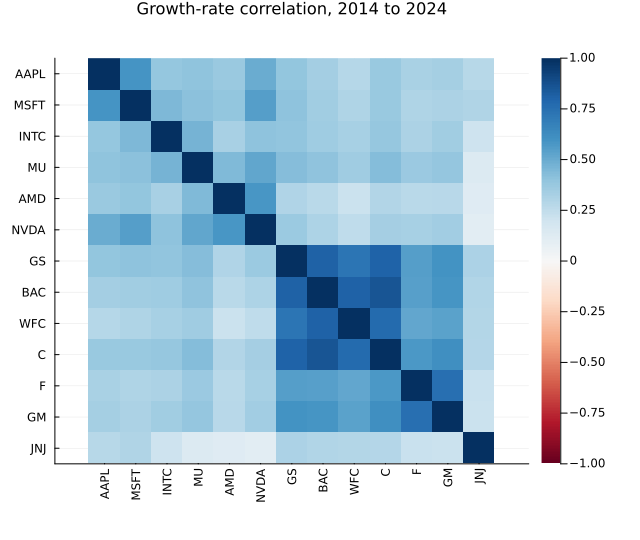

In [9]:
let
    M = length(my_list_of_tickers);
    heatmap(ρ̂, xticks = (1:M, my_list_of_tickers), yticks = (1:M, my_list_of_tickers), xrotation = 90,
        color = :RdBu, clims = (-1, 1), colorbar_ticks = (-1:0.5:1), aspect_ratio = :equal, yflip = true,
        title = "Growth-rate correlation, 2014 to 2024", titlefontsize = 11, right_margin = 10Plots.mm, size = (640, 540))
end

Firms in the same industry move together (the banks most strongly, the semiconductor firms with each other), while the health-care firm is only weakly correlated with everything else. Those off-diagonal entries are what the optimizer exploits.

___

## Task 2: The Global Minimum-Variance Portfolio
In this task, we compute the global minimum-variance portfolio first without sign constraints and then with long-only bounds, so the cost of the constraint is visible.

The global minimum-variance (GMV) portfolio is the fully invested portfolio with the smallest growth-rate variance $\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_{g}\mathbf{w}$, with no growth target at all. When short positions are allowed and only the budget constraint $\mathbf{1}^{\top}\mathbf{w}=1$ is imposed, the lecture derives the closed form:
$$
\mathbf{w}_{\text{GMV}} = \frac{\hat{\mathbf{\Sigma}}_{g}^{-1}\mathbf{1}}{\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_{g}^{-1}\mathbf{1}},\qquad
\sigma^{2}_{\text{GMV}} = \frac{1}{\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_{g}^{-1}\mathbf{1}},
$$
where $\mathbf{1}\in\mathbb{R}^{M}$ is a vector of ones. We compute $\hat{\mathbf{\Sigma}}_{g}^{-1}\mathbf{1}$ by solving a linear system with [the backslash operator](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/) rather than forming the inverse, and store the weights and the standard deviation in the `w_GMV_closed::Array{Float64,1}` and `σ_GMV_closed::Float64` variables:

In [10]:
w_GMV_closed, σ_GMV_closed = let
    M = length(my_list_of_tickers);
    one_vector = ones(M);
    x = Σ̂_g \ one_vector; # x = Σ̂_g⁻¹ 1
    w = x / (one_vector'*x); # closed-form GMV weights
    σ = sqrt(1/(one_vector'*x)); # closed-form GMV growth-rate standard deviation (units: 1/years)
    @assert isapprox(σ, sqrt(w'*Σ̂_g*w), rtol = 1e-10) # same thing computed two ways
    (w, σ); # Return
end;

Some of these weights are negative (short positions), which the closed form does not forbid. The lecture's long-only problem adds $w_{i}\geq{0}$, which turns the problem into a quadratic program with no closed form. We solve it with the course package: create an instance of [the `MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem) [using the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.build-Tuple{Type{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem},%20NamedTuple}), then call [the `solve(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.solve-Tuple{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem}), which sets up and solves:
$$
\begin{align*}
\text{minimize}~&\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_{g}\mathbf{w}\\
\text{subject to}~&\hat{\mathbf{g}}^{\top}\mathbf{w}\geq g_{\star},\quad \mathbf{1}^{\top}\mathbf{w} = 1,\quad 0\leq w_{i}\leq 1,
\end{align*}
$$
using [JuMP](https://jump.dev/JuMP.jl/stable/) with the [MadNLP](https://github.com/MadNLP/MadNLP.jl) solver. The package names the fields `Σ` (the covariance in the objective), `μ` (the vector of expected growth rates; the name is a legacy of the package, not the GBM drift), `R` (the target $g_{\star}$, a lower bound), `bounds` (one row per asset), and `initial` (a starting point); the results dictionary retains the legacy key `argmax` for the minimizing weights, and the returned `objective_value` is the variance $\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_{g}\mathbf{w}$, not its square root. For the GMV portfolio, we make the target constraint slack by setting $g_{\star}$ to the smallest single-firm mean growth rate, which every fully invested long-only portfolio meets. We store the problem in the `problem::MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem` variable and the long-only GMV weights in the `w_GMV::Array{Float64,1}` variable:

In [11]:
problem = let
    M = length(my_list_of_tickers);
    bounds = zeros(M, 2); bounds[:,2] .= 1.0; # 0 ≤ wᵢ ≤ 1 (long only, no leverage)
    build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (
        Σ = Σ̂_g, # growth-rate covariance matrix
        μ = ĝ, # package field μ holds the expected growth rates ĝ
        bounds = bounds, # weight bounds
        initial = (1/M)*ones(M), # start from equal weights
        R = minimum(ĝ) # target growth rate g⋆; slack for the GMV portfolio
    ));
end;

w_GMV = let
    solution = solve(problem); # solve the long-only problem
    @assert solution["status"] == MathOptInterface.LOCALLY_SOLVED
    solution["argmax"]; # long-only GMV weights
end;

Do the two agree? Let's put the two weight vectors side by side, together with each portfolio's expected growth rate and growth-rate standard deviation:

In [12]:
let
    df = DataFrame(ticker = my_list_of_tickers, w_closed_form = round.(w_GMV_closed, digits=4), w_long_only = round.(w_GMV, digits=4) .+ 0.0);
    push!(df, (ticker = "sum", w_closed_form = round(sum(w_GMV_closed), digits=4), w_long_only = round(sum(w_GMV), digits=4)));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    
    σ_long_only = sqrt(w_GMV'*Σ̂_g*w_GMV);
    @assert σ_long_only ≥ σ_GMV_closed - 1e-8 # the constrained minimum can never beat the unconstrained one
    println("Closed form: E[g] = $(round(ĝ'*w_GMV_closed, digits=4)) 1/yr, σ = $(round(σ_GMV_closed, digits=4)) 1/yr")
    println("Long only:   E[g] = $(round(ĝ'*w_GMV, digits=4)) 1/yr, σ = $(round(σ_long_only, digits=4)) 1/yr")
end

 -------- --------------- -------------
  ticker   w_closed_form   w_long_only 
  String         Float64       Float64 
 -------- --------------- -------------
    AAPL          0.0994        0.0901
    MSFT          0.1506        0.1423
    INTC          0.0486         0.041
      MU         -0.0112           0.0
     AMD         -0.0042           0.0
    NVDA         -0.0065           0.0
      GS          0.0662        0.0236
     BAC          0.0155           0.0
     WFC          0.0876        0.0595
       C         -0.0926           0.0
       F          0.0201        0.0137
      GM           0.011         0.002
     JNJ          0.6155        0.6278
     sum             1.0           1.0
 -------- --------------- -------------
Closed form: E[g] = 0.0836 1/yr, σ = 2.1635 1/yr


Long only:   E[g] = 0.0818 1/yr, σ = 2.1749 1/yr


The closed form shorts several of the volatile names to hedge the others, and its standard deviation is smaller, as it must be: the long-only optimum lives in a subset of the unconstrained feasible set. Both portfolios put most of the wealth in JNJ, the low-variance health-care name in this selected universe, which is what these estimates lead a variance minimizer with no growth target to do. Neither weight vector is a recommendation; both are functions of eleven years of estimates that will not repeat.

___

## Task 3: The Efficient Frontier
In this task, we sweep the required growth rate, solve the long-only problem at each target, and compare the resulting efficient branch with the unconstrained closed-form frontier.

Now we add a target growth rate $g_{\star}$ and sweep it. For each target we solve the long-only problem above and record the resulting expected growth rate $\hat{\mathbf{g}}^{\top}\mathbf{w}$, the growth-rate standard deviation $\sigma_{g,p}=\sqrt{\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_{g}\mathbf{w}}$, and the weights. Because the package writes the target as $\hat{\mathbf{g}}^{\top}\mathbf{w}\geq g_{\star}$, every target below the GMV portfolio's expected growth rate returns the GMV portfolio again, so we start the sweep at $\hat{\mathbf{g}}^{\top}\mathbf{w}_{\text{GMV}}$ and stop just below the largest single-firm mean growth rate, the most a long-only portfolio can promise. With the target written as an inequality, the sweep returns the GMV portfolio and then the __efficient branch__ of the frontier; the lower branch (same variance, less growth) is minimum-variance for its growth rate but is only reached with an equality target, which the closed form below uses.

Why the [try-catch construct](https://docs.julialang.org/en/v1/base/base/#try)? [The `solve(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.solve-Tuple{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem}) asserts that the optimization converged and throws otherwise; a target at the very edge of the feasible set can fail, and we simply skip it. We store the sweep in the `frontier_df::DataFrame` variable, one row per solved target, in target order:

In [13]:
frontier_df = let

    # Initialize -
    df = DataFrame(g_target = Float64[], g = Float64[], σ = Float64[], w = Vector{Float64}[]);
    g_low = ĝ'*w_GMV; # expected growth rate of the long-only GMV portfolio
    g_high = maximum(ĝ) - 1e-4; # just below the best single firm (a target above it is infeasible for a long-only portfolio)
    targets = range(g_low, stop = g_high, length = number_of_points) |> collect; # includes both endpoints

    # main loop: solve for each target -
    for target ∈ targets
        problem.R = target; # update the target growth rate g⋆
        try
            solution = solve(problem);
            if (solution["status"] == MathOptInterface.LOCALLY_SOLVED)
                w = solution["argmax"];
                push!(df, (g_target = target, g = ĝ'*w, σ = sqrt(w'*Σ̂_g*w), w = w));
            end
        catch err
            err isa AssertionError || rethrow() # the package asserts convergence; anything else is a real error
        end
    end
    df; # Return
end;
println("Solved $(nrow(frontier_df)) of $(number_of_points) targets; grid spacing in g⋆ = $(round(frontier_df.g_target[2] - frontier_df.g_target[1], digits=5)) 1/yr")

Solved 101 of 101 targets; grid spacing in g⋆ = 0.0045 1/yr


For comparison, when short positions are allowed and the target is an equality, the minimum-variance frontier has a closed form: with $a=\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_{g}^{-1}\mathbf{1}$, $b=\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_{g}^{-1}\hat{\mathbf{g}}$, $c=\hat{\mathbf{g}}^{\top}\hat{\mathbf{\Sigma}}_{g}^{-1}\hat{\mathbf{g}}$, and $d=ac-b^{2}$ (positive as long as the firms do not all have the same mean growth rate, which we check), the smallest variance that reaches expected growth rate $g$ is:
$$
\sigma^{2}(g) = \frac{a\,g^{2}-2b\,g+c}{d},
$$
which is a hyperbola in the $(\sigma, g)$ plane with its vertex at the GMV portfolio, $g=b/a$ and $\sigma^{2}=1/a$ (the same result as Task 2; we assert it below). Both branches of the hyperbola are minimum-variance portfolios; only the upper branch is efficient. Let's compute the unconstrained frontier over a range of growth rates and store it in the `hyperbola_df::DataFrame` variable:

In [14]:
hyperbola_df = let
    M = length(my_list_of_tickers);
    one_vector = ones(M);
    x = Σ̂_g \ one_vector; # Σ̂_g⁻¹ 1
    y = Σ̂_g \ ĝ; # Σ̂_g⁻¹ ĝ
    a = one_vector'*x; b = one_vector'*y; c = ĝ'*y; d = a*c - b^2;
    @assert d > 0 # the mean growth rates are not all equal
    @assert isapprox(sqrt(1/a), σ_GMV_closed, rtol = 1e-10) # vertex of the hyperbola is the closed-form GMV portfolio
    @assert isapprox(b/a, ĝ'*w_GMV_closed, rtol = 1e-10)
    g_range = range(minimum(ĝ) - 0.05, stop = maximum(ĝ) + 0.05, length = 201) |> collect;
    σ_range = [sqrt((a*g^2 - 2*b*g + c)/d) for g ∈ g_range];
    DataFrame(g = g_range, σ = σ_range)
end;

Let's plot the long-only efficient frontier (solid), the unconstrained hyperbola (dashed), the individual firms, the equal-weight portfolio, and the two GMV portfolios. `Unhide` the code block below to see how we made the plot [using the `plot(...)` function](https://docs.juliaplots.org/stable/api/#Plots.plot-Tuple):

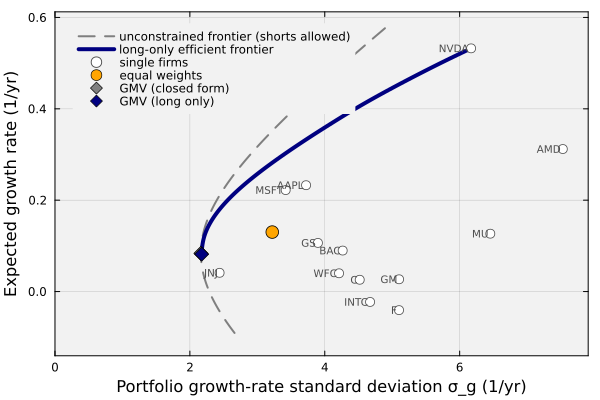

In [15]:
let
    M = length(my_list_of_tickers);
    σ_single = sqrt.(diag(Σ̂_g)); # single-firm growth-rate standard deviations
    w_eq = (1/M)*ones(M);

    plot(hyperbola_df.σ, hyperbola_df.g, ls = :dash, lw = 2, c = :gray50, label = "unconstrained frontier (shorts allowed)")
    plot!(frontier_df.σ, frontier_df.g, lw = 4, c = :navy, label = "long-only efficient frontier")
    scatter!(σ_single, ĝ, ms = 5, c = :white, msc = :gray30, label = "single firms")
    for i ∈ 1:M
        annotate!(σ_single[i] - 0.04, ĝ[i], text(my_list_of_tickers[i], 7, :right, :gray30))
    end
    scatter!([sqrt(w_eq'*Σ̂_g*w_eq)], [ĝ'*w_eq], ms = 7, c = :orange, label = "equal weights")
    scatter!([σ_GMV_closed], [ĝ'*w_GMV_closed], ms = 7, c = :gray50, marker = :diamond, label = "GMV (closed form)")
    scatter!([sqrt(w_GMV'*Σ̂_g*w_GMV)], [ĝ'*w_GMV], ms = 7, c = :navy, marker = :diamond, label = "GMV (long only)")
    plot!(xlabel = "Portfolio growth-rate standard deviation σ_g (1/yr)", ylabel = "Expected growth rate (1/yr)", 
        xlim = (0.0, 1.05*maximum(σ_single)), ylim = (min(minimum(ĝ), minimum(hyperbola_df.g)) - 0.05, maximum(ĝ) + 0.08),
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

Three things to notice. Every single firm except the one with the highest mean growth rate sits strictly to the right of the frontier, so for any growth rate those firms offer, some mixture reaches it with less variance: that is diversification. The long-only frontier ends at the best single firm (the sweep stops just below its mean, so the last solved portfolio holds almost all of its weight there) and lies on or to the right of the unconstrained hyperbola, because forbidding short positions removes feasible portfolios; the two frontiers touch only where the unconstrained solution happens to be long-only. And the equal-weight portfolio is not far from the frontier, a point we return to in the last task.

Which firms carry the frontier as the target rises? Let's look at the weights along the frontier as a stacked area chart [using the `areaplot(...)` function](https://docs.juliaplots.org/stable/api/#Plots.areaplot-Tuple), and then in a table at three points (the GMV portfolio, the middle of the sweep, and the last solved target):

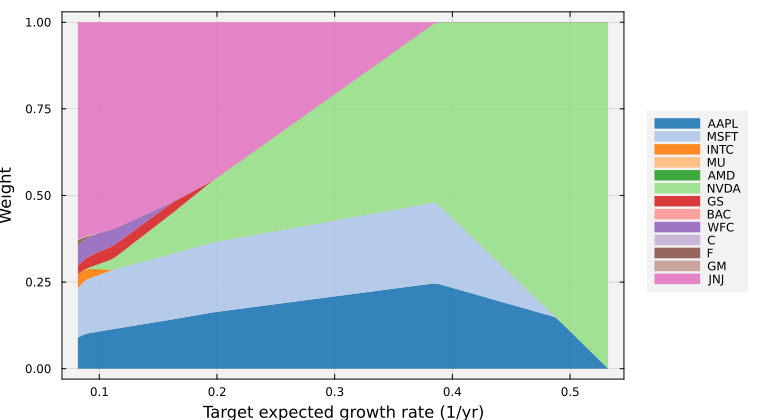

In [16]:
let
    W = hcat(frontier_df.w...)'; # rows are frontier points, columns are firms
    areaplot(frontier_df.g, W, labels = permutedims(my_list_of_tickers), lw = 0, alpha = 0.9, palette = :tab20,
        xlabel = "Target expected growth rate (1/yr)", ylabel = "Weight", legend = :outerright,
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, size = (760, 420))
end

In [17]:
let
    k_mid = round(Int, nrow(frontier_df)/2);
    k_end = nrow(frontier_df);
    df = DataFrame(ticker = my_list_of_tickers, w_GMV = round.(frontier_df.w[1], digits=4) .+ 0.0, 
        w_mid = round.(frontier_df.w[k_mid], digits=4) .+ 0.0, w_high = round.(frontier_df.w[k_end], digits=4) .+ 0.0);
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    for (name, k) ∈ [("GMV", 1), ("mid", k_mid), ("high", k_end)]
        println("$(name): E[g] = $(round(frontier_df.g[k], digits=4)) 1/yr, σ = $(round(frontier_df.σ[k], digits=4)) 1/yr")
    end
end

 -------- --------- --------- ---------
  ticker     w_GMV     w_mid    w_high 
  String   Float64   Float64   Float64 
 -------- --------- --------- ---------
    AAPL    0.0902    0.2098    0.0003
    MSFT    0.1423    0.2196       0.0
    INTC     0.041       0.0       0.0
      MU       0.0       0.0       0.0
     AMD       0.0       0.0       0.0
    NVDA       0.0    0.3694    0.9997
      GS    0.0236       0.0       0.0
     BAC       0.0       0.0       0.0
     WFC    0.0595       0.0       0.0
       C       0.0       0.0       0.0
       F    0.0137       0.0       0.0
      GM     0.002       0.0       0.0
     JNJ    0.6277    0.2012       0.0
 -------- --------- --------- ---------
GMV: E[g] = 0.0818 1/yr, σ = 2.1749 1/yr
mid: E[g] = 0.3025 1/yr, σ = 3.4184 1/yr
high: E[g] = 0.5323 1/yr, σ = 6.1678 1/yr


As the target rises, the optimizer drops the low-growth names one by one and concentrates in the firms with the highest estimated mean growth, until the frontier ends at the best single firm. Concentration is the price of a high growth target under these estimates.

___

## Task 4: A Risk-Free Asset, the Tangent Portfolio, and the Capital Allocation Line
In this task, we add a horizon-matched risk-free rate, find the long-only maximum-Sharpe grid candidate, and draw its capital allocation line.

Now let a risk-free asset with growth rate $g_{f}$ join the menu. Putting a fraction $w_{f}$ of wealth in the risk-free asset and $1-w_{f}$ in a risky portfolio $p$ gives a complete portfolio $c$ with expected growth rate $\mathbb{E}[g_{c}]=g_{f}+(1-w_{f})(\mathbb{E}[g_{p}]-g_{f})$ and standard deviation $\sigma_{g,c}=|1-w_{f}|\,\sigma_{g,p}$, so for $w_{f}\leq1$ it moves along the straight line from $(0, g_{f})$ through $p$ in the $(\sigma_{g}, g)$ plane: the capital allocation line (CAL). Its slope is the Sharpe ratio of $p$:
$$
\text{SR}_{p} = \frac{\mathbb{E}[g_{p}]-g_{f}}{\sigma_{g,p}}.
$$
The __tangent portfolio__ $\mathcal{T}$ is the risky portfolio with the largest Sharpe ratio; its CAL touches the efficient frontier and dominates every other CAL, provided some feasible portfolio has $\mathbb{E}[g_{p}]>g_{f}$ (we check). Along the long-only frontier we have already solved for, we evaluate the Sharpe ratio at every point from the achieved growth rates and take the largest [using the `argmax(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.argmax); this is a __grid candidate__ for the tangent portfolio, accurate to the grid spacing printed above. We store its weights in the `w_tan::Array{Float64,1}` variable and its index along the frontier in the `k_tan::Int64` variable:

In [18]:
k_tan, w_tan = let
    SR = (frontier_df.g .- g_f) ./ frontier_df.σ; # Sharpe ratio (one observation interval) at each frontier point
    k = argmax(SR);
    @assert SR[k] > 0 # some long-only portfolio beats the risk-free rate in expectation
    (k, frontier_df.w[k]); # Return
end;

When short positions are allowed, the lecture gives the tangent portfolio in closed form, $\mathbf{w}_{\mathcal{T}}\propto\hat{\mathbf{\Sigma}}_{g}^{-1}(\hat{\mathbf{g}}-g_{f}\mathbf{1})$ normalized to sum to one, valid when $\hat{\mathbf{\Sigma}}_{g}$ is positive definite and the normalizing constant $\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_{g}^{-1}(\hat{\mathbf{g}}-g_{f}\mathbf{1})$ is positive (equivalently, the GMV portfolio earns more than $g_{f}$ in expectation; we check). Let's compute it for comparison, in the `w_tan_closed::Array{Float64,1}` variable:

In [19]:
w_tan_closed = let
    M = length(my_list_of_tickers);
    x = Σ̂_g \ (ĝ .- g_f*ones(M)); # Σ̂_g⁻¹ (ĝ - g_f 1)
    @assert sum(x) > 0 # 1ᵀ Σ̂_g⁻¹ (ĝ - g_f 1) > 0, so the normalized vector is the maximum-Sharpe portfolio
    x / sum(x); # normalize to a fully invested portfolio
end;

How different are they, and what Sharpe ratios do they carry? The Sharpe ratio above is the CAL slope in growth-rate units: numerator and denominator are both in inverse years, so it is dimensionless, and because $\sigma_{g,p}$ is the standard deviation of a __one-day__ growth rate it is the Sharpe ratio of a one-observation-interval holding period. The convention in practice divides by the __volatility__ instead, $\sqrt{\mathbf{w}^{\top}\hat{\mathbf{C}}\mathbf{w}}=\sqrt{\Delta{t}}\,\sigma_{g,p}$, which gives the annualized Sharpe ratio $\text{SR}_{p}/\sqrt{\Delta{t}}$, larger by $\sqrt{252}\approx 15.9$ for daily data. The two conventions rank portfolios identically, so they pick the same tangent portfolio; we print both:

In [20]:
let
    df = DataFrame(ticker = my_list_of_tickers, w_tan_long_only = round.(w_tan, digits=4) .+ 0.0, w_tan_closed_form = round.(w_tan_closed, digits=4));
    push!(df, (ticker = "sum", w_tan_long_only = round(sum(w_tan), digits=4), w_tan_closed_form = round(sum(w_tan_closed), digits=4)));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))

    for (name, w) ∈ [("long only", w_tan), ("closed form", w_tan_closed)]
        g = ĝ'*w; σ = sqrt(w'*Σ̂_g*w); SR = (g - g_f)/σ;
        println("Tangent ($(name)): E[g] = $(round(g, digits=4)) 1/yr, σ_g = $(round(σ, digits=4)) 1/yr, SR = $(round(SR, digits=4)) (one-day interval), annualized SR = $(round(SR/sqrt(Δt), digits=3))")
    end
end

 -------- ----------------- -------------------
  ticker   w_tan_long_only   w_tan_closed_form 
  String           Float64             Float64 
 -------- ----------------- -------------------
    AAPL            0.2013              0.9105
    MSFT            0.1254              0.8981
    INTC               0.0             -1.2905
      MU               0.0             -0.3306
     AMD               0.0             -0.0969
    NVDA            0.6733              1.7119
      GS               0.0              0.8209
     BAC               0.0              1.3224
     WFC               0.0             -0.1146
       C               0.0             -1.5773
       F               0.0             -0.9966
      GM               0.0              0.0965
     JNJ               0.0             -0.3537
     sum               1.0                 1.0
 -------- ----------------- -------------------
Tangent (long only): E[g] = 0.4332 1/yr, σ_g = 4.8455 1/yr, SR = 0.0809 (one-day interval), annualized


Tangent (closed form): E[g] = 1.4695 1/yr, σ_g = 12.5284 1/yr, SR = 0.114 (one-day interval), annualized SR = 1.81


The unconstrained tangent portfolio takes large long and short positions, several of them larger than the whole budget, because $\hat{\mathbf{\Sigma}}_{g}^{-1}$ amplifies small differences in the estimated mean growth rates. Its Sharpe ratio is higher, on the training data, than the long-only tangent portfolio's, which is what an extra constraint costs in sample. Nobody should read those weights as a plan; they are the clearest picture in this notebook of how sensitive mean-variance optimization is to its inputs.

Let's draw the CAL through the long-only tangent portfolio on top of the frontier. `Unhide` the code block below to see how:

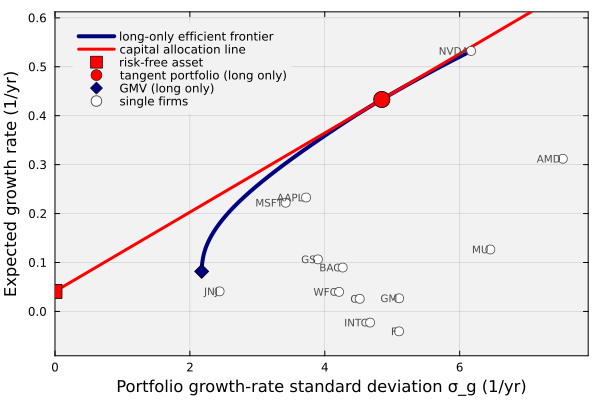

In [21]:
let
    M = length(my_list_of_tickers);
    σ_single = sqrt.(diag(Σ̂_g));
    σ_tan = frontier_df.σ[k_tan]; g_tan = frontier_df.g[k_tan]; SR_tan = (g_tan - g_f)/σ_tan;
    σ_max = 1.05*maximum(σ_single);

    plot(frontier_df.σ, frontier_df.g, lw = 4, c = :navy, label = "long-only efficient frontier")
    plot!([0.0, σ_max], [g_f, g_f + SR_tan*σ_max], lw = 3, c = :red, label = "capital allocation line")
    scatter!([0.0], [g_f], ms = 7, c = :red, marker = :square, label = "risk-free asset")
    scatter!([σ_tan], [g_tan], ms = 9, c = :red, label = "tangent portfolio (long only)")
    scatter!([frontier_df.σ[1]], [frontier_df.g[1]], ms = 7, c = :navy, marker = :diamond, label = "GMV (long only)")
    scatter!(σ_single, ĝ, ms = 5, c = :white, msc = :gray30, label = "single firms")
    for i ∈ 1:M
        annotate!(σ_single[i] - 0.04, ĝ[i], text(my_list_of_tickers[i], 7, :right, :gray30))
    end
    plot!(xlabel = "Portfolio growth-rate standard deviation σ_g (1/yr)", ylabel = "Expected growth rate (1/yr)", 
        xlim = (0.0, σ_max), ylim = (min(0.0, minimum(ĝ)) - 0.05, maximum(ĝ) + 0.08),
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

Points on the CAL to the left of the tangent portfolio lend some wealth at $g_{f}$ ($0<w_{f}<1$); points to the right borrow at $g_{f}$ to hold more than the whole budget in $\mathcal{T}$ ($w_{f}<0$), which assumes we can borrow at the lending rate. Every point on the line beats the risky frontier at the same standard deviation, which is the two-fund separation result: with a risk-free asset and no other constraints, all mean-variance investors hold the same risky fund and differ only in $w_{f}$. Note that everything on this line is a statement about the one-period growth statistic $\mathbf{w}^{\top}\mathbf{g}$; the next task evaluates the same weights with the buy-and-hold wealth rule, which is a different (and exact) calculation.

___

## Task 5: How Did the Portfolios Do Out of Sample?
In this task, we hold the training-period weights fixed and compare their realized buy-and-hold wealth and daily growth-rate risk on 2025 prices.

Everything above was estimated from 2014 to 2024. Let's see how the long-only GMV portfolio, the long-only tangent portfolio, an equal-weight portfolio, and the [SPY ETF](https://en.wikipedia.org/wiki/SPDR_S%26P_500) (a proxy for the S&P 500 index) would have done as __buy-and-hold__ portfolios in calendar year 2025, using the testing data. Buy-and-hold wealth for initial weights $\mathbf{w}$ and initial wealth $W_{0}$ is $W_{t}=W_{0}\sum_{i}w_{i}\,S_{i}(t)/S_{i}(0)$ (L5a); we use the volume-weighted average price for $S_{i}(t)$, the same first trading day and the same $W_{0}$ for every portfolio, and weights fixed from the training data. Note that the optimizer worked with the one-period growth statistic $\mathbf{w}^{\top}\mathbf{g}$, while wealth compounds the actual price ratios, so this is a test of the weights, not of the linearized objective. First, we build the 2025 price matrix (rows are trading days, columns are firms) and store it in the `prices_2025::Array{Float64,2}` variable:

In [22]:
prices_2025 = let
    N = nrow(dataset_2025["AAPL"]); M = length(my_list_of_tickers);
    S = Array{Float64,2}(undef, N, M);
    for (i, ticker) ∈ enumerate(my_list_of_tickers)
        S[:,i] = dataset_2025[ticker][:, :volume_weighted_average_price];
    end
    S; # Return
end;

Next, we compute the wealth paths. Each is a vector with one entry per trading day; we collect them in the `wealth_2025::Dict{String,Array{Float64,1}}` variable, keyed by portfolio name:

In [23]:
wealth_2025 = let
    M = length(my_list_of_tickers);
    price_ratio = prices_2025 ./ prices_2025[1,:]'; # S_i(t)/S_i(0), one column per firm
    wealth = Dict{String, Array{Float64,1}}();
    for (name, w) ∈ [("GMV (long only)", w_GMV), ("tangent (long only)", w_tan), ("equal weights", (1/M)*ones(M))]
        wealth[name] = W₀*(price_ratio*w); # buy-and-hold wealth path
    end
    spy = dataset_2025["SPY"][:, :volume_weighted_average_price];
    wealth["SPY"] = W₀*(spy ./ spy[1]);
    wealth; # Return
end;

Let's plot the four scaled wealth paths, $W_{t}/W_{0}$, over the 2025 trading days. `Unhide` the code block below to see how:

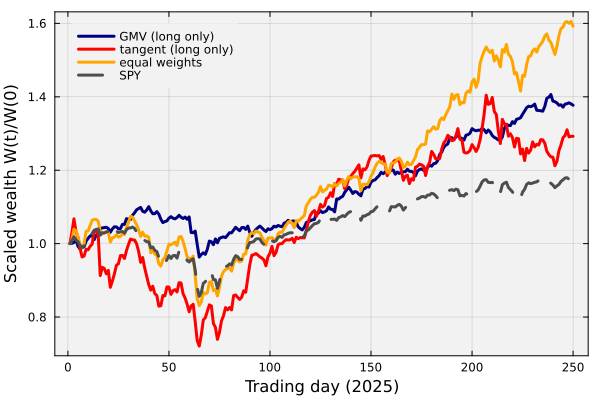

In [24]:
let
    p = plot();
    for (name, c, ls) ∈ [("GMV (long only)", :navy, :solid), ("tangent (long only)", :red, :solid), ("equal weights", :orange, :solid), ("SPY", :gray30, :dash)]
        plot!(wealth_2025[name] ./ W₀, lw = 3, c = c, ls = ls, label = name)
    end
    plot!(xlabel = "Trading day (2025)", ylabel = "Scaled wealth W(t)/W(0)", 
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

Finally, a scorecard: the year-end wealth ratio, the realized 2025 growth rate $\ln(W_{T}/W_{0})/T$ with $T$ in years, and the realized growth-rate standard deviation of each wealth path (the daily log growth of wealth, in the same units as the training estimates), [using the `diff(...)` function](https://docs.julialang.org/en/v1/base/arrays/#Base.diff) for the daily log changes:

In [25]:
let
    df = DataFrame(portfolio = String[], W_T_over_W_0 = Float64[], growth_2025 = Float64[], σ_g_2025 = Float64[]);
    for name ∈ ["GMV (long only)", "tangent (long only)", "equal weights", "SPY"]
        W = wealth_2025[name]; T = (length(W) - 1)*Δt; # holding period in years
        g_daily = diff(log.(W)) ./ Δt; # realized daily growth rates of wealth (units: 1/years)
        push!(df, (portfolio = name, W_T_over_W_0 = round(W[end]/W[1], digits=4), growth_2025 = round(log(W[end]/W[1])/T, digits=4), σ_g_2025 = round(std(g_daily), digits=3)));
    end
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 --------------------- -------------- ------------- ----------
            portfolio   W_T_over_W_0   growth_2025   σ_g_2025 
               String        Float64       Float64    Float64 
 --------------------- -------------- ------------- ----------
      GMV (long only)          1.377        0.3238      1.996
  tangent (long only)         1.2924        0.2596      5.113
        equal weights         1.5921        0.4706      3.487
                  SPY         1.1691        0.1581      2.206
 --------------------- -------------- ------------- ----------


Read the scorecard for what it is: one year, one draw, four portfolios, and a universe fixed before the year began. The GMV portfolio has the smallest realized standard deviation here, which is what we expect if the covariance estimate carried over; whether the tangent portfolio's growth advantage carried over depends on whether the 2014 to 2024 mean growth rates persisted, and that is the input we already saw is the least certain. A single split like this is a sanity check, not a validation of the method; a proper test refits the inputs only on data available before each decision, includes trading costs, and repeats over many periods.

___

## Summary
In this example, we estimated growth-rate means and covariances for a chosen set of firms, computed the global minimum-variance portfolio in closed form and with a long-only solver, traced the efficient frontier, added a risk-free asset to find the tangent portfolio and the capital allocation line, and compared the optimized portfolios with equal weights and an index fund on a year of data the optimizer never saw.

> __Key Takeaways:__
>
> * **The frontier is a computation on two estimates:** The mean growth-rate vector and the covariance matrix from the training data determine every portfolio here, and the sweep over target growth rates traces only the efficient branch because the solver treats the target as a floor.
> * **Constraints change the solution materially:** The unconstrained closed forms for the minimum-variance and tangent portfolios take large short and leveraged positions that the long-only solver forbids. This comparison isolates sensitivity to the feasible set; the advanced estimation-risk notebook tests sensitivity to the estimated inputs separately.
> * **Out-of-sample performance checks persistence:** In this one-year check the minimum-variance portfolio kept the lowest realized risk while the tangent portfolio's growth advantage did not carry over, which is consistent with unstable mean-growth estimates, but one year and one universe are a check rather than a validation.

The lecture takes the same machinery to its conclusion, the market portfolio and the assumptions behind it, and L6a replaces the full covariance matrix with a single-index model that needs far fewer estimates.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
